### Análisis de datos II
## Clustering. Repaso.
### K-means. GMM. Clustering jerárquico.

Ejemplos con dataset sintético.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---
### DATASET SINTÉTICO

In [2]:
from sklearn.datasets import make_blobs

In [3]:
X, _ = make_blobs(
    n_samples=750,
    centers=[[1, 1], [-1, -1], [1.2, -1.2]],
    cluster_std=[0.5, 0.1, 0.75],
    random_state=0
)
X.shape

(750, 2)

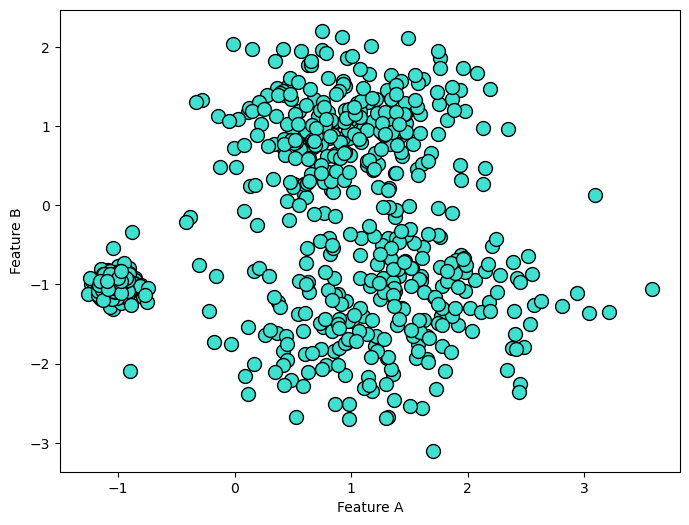

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(X[:, 0], X[:, 1],
                "o",
                markerfacecolor='turquoise',
                markeredgecolor="k",
                markersize=10)
plt.xlabel("Feature A")
plt.ylabel("Feature B")
plt.show()

---
### K-means

In [5]:
from sklearn.cluster import KMeans

In [6]:
K = 3
clusters = KMeans(n_clusters = K, init="k-means++", max_iter=300, n_init=10, random_state=42).fit_predict(X)

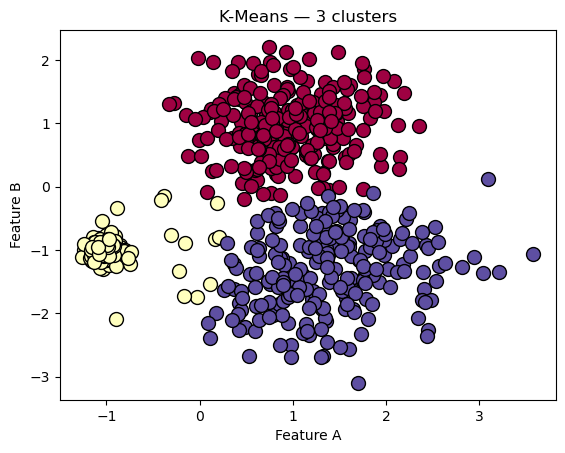

In [7]:
unique_labels = set(clusters)

colors = [
    plt.cm.Spectral(each)
    for each in np.linspace(0, 1, len(unique_labels))
]

for k, col in zip(unique_labels, colors):

    class_member_mask = clusters == k

    xy = X[class_member_mask]

    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=10,
    )

plt.xlabel("Feature A")
plt.ylabel("Feature B")
plt.title(f"K-Means — {K} clusters")
plt.show()

#### Probemos con distinto número de K

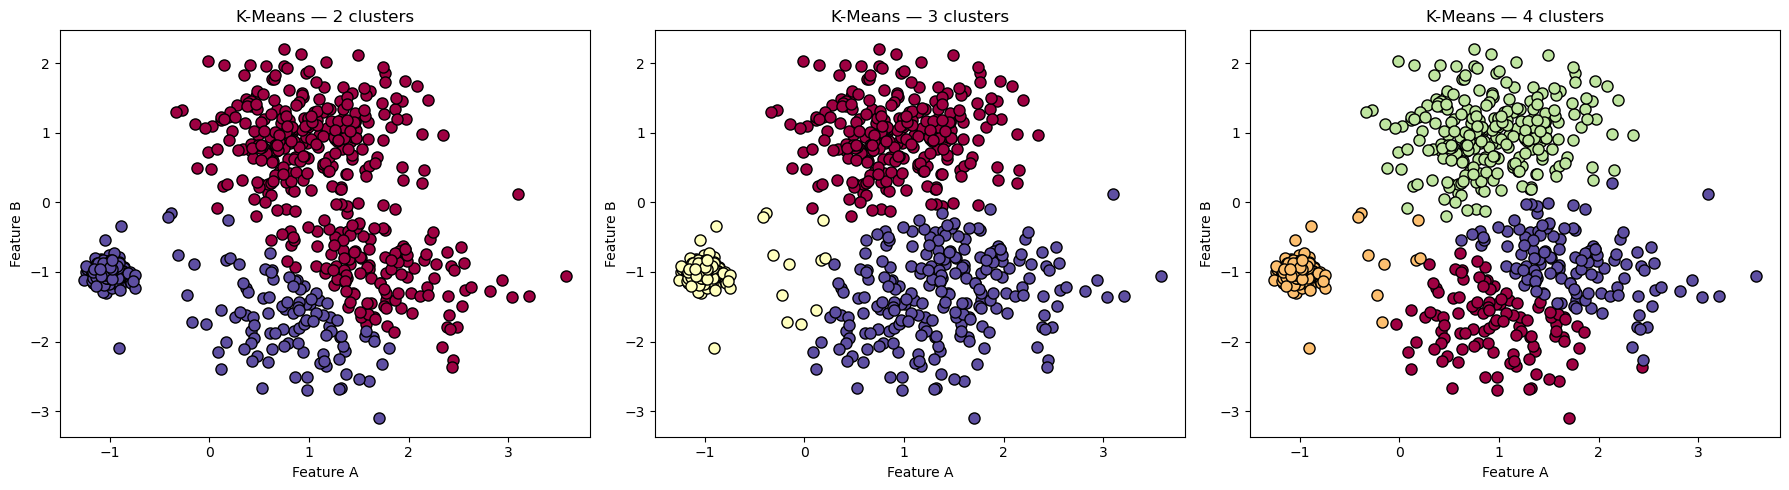

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, K in zip(axes, [2, 3, 4]):

    kmeans = KMeans(n_clusters=K,  init = "k-means++", random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X)

    unique_labels = set(clusters)

    colors = [
        plt.cm.Spectral(each)
        for each in np.linspace(0, 1, len(unique_labels))
    ]

    for k, col in zip(unique_labels, colors):

        class_member_mask = clusters == k
        xy = X[class_member_mask]

        ax.plot(
            xy[:, 0],
            xy[:, 1],
            "o",
            markerfacecolor=tuple(col),
            markeredgecolor="k",
            markersize=8,
        )

    ax.set_xlabel("Feature A")
    ax.set_ylabel("Feature B")
    ax.set_title(f"K-Means — {K} clusters")

plt.tight_layout()
plt.show()

---
### GMM

In [9]:
from sklearn.mixture import GaussianMixture

In [10]:
K = 3
gmm = GaussianMixture(n_components=K, covariance_type='full',random_state=0)
gmm = gmm.fit(X)
clusters_gmm = gmm.predict(X)
proba = gmm.predict_proba(X)

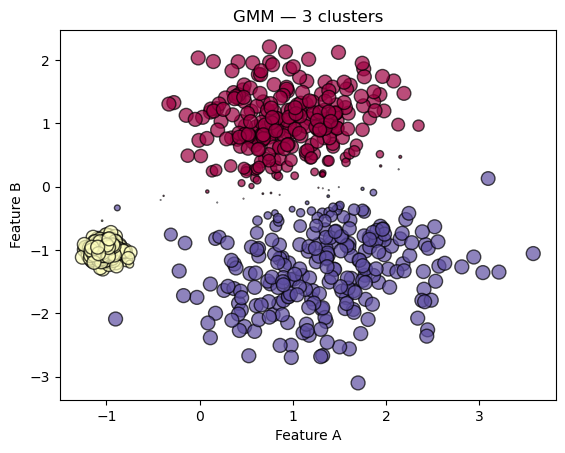

In [11]:
# para definir los tamaños de los puntos
prob = proba[np.arange(len(clusters_gmm)), clusters_gmm]
sizes = 100 * prob**10

unique_labels = set(clusters_gmm)

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):

    class_member_mask = clusters_gmm == k
    
    xy = X[class_member_mask]
    sizes_k = sizes[class_member_mask]

    plt.scatter(xy[:, 0], xy[:, 1], s=sizes_k,
        c=[tuple(col)], edgecolor="k", alpha=0.7)

plt.xlabel("Feature A")
plt.ylabel("Feature B")
plt.title(f"GMM — {K} clusters")
plt.show()

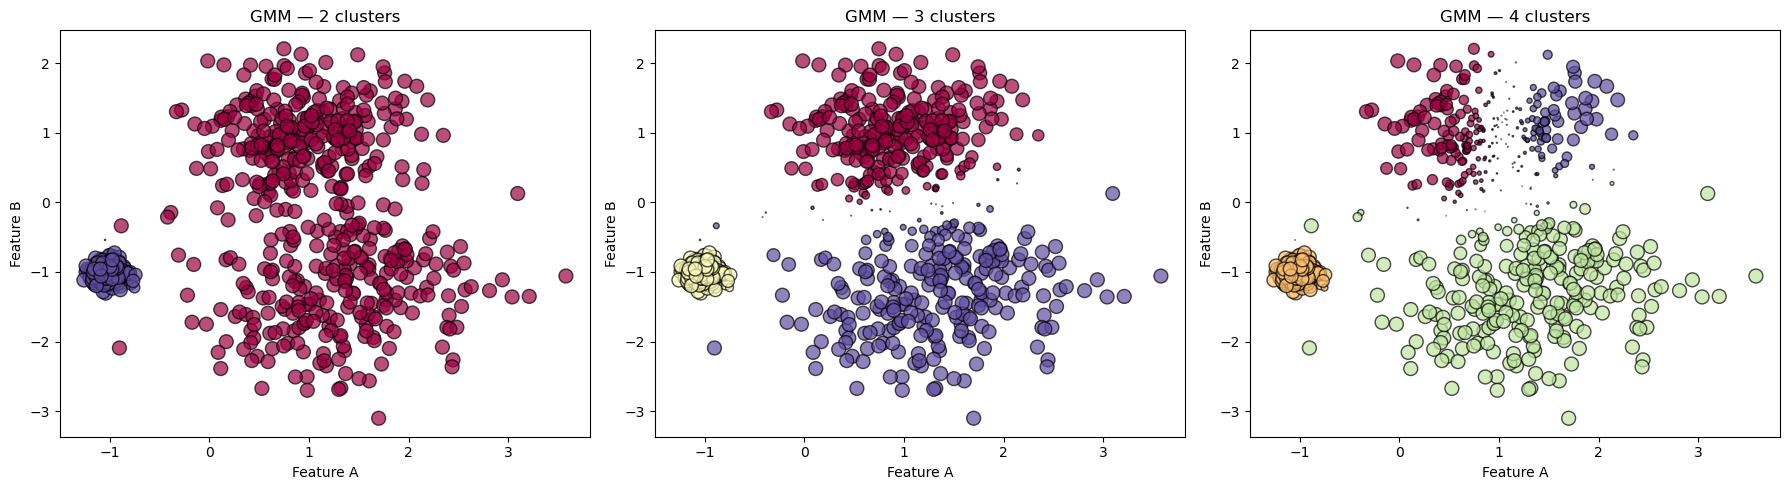

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, K in zip(axes, [2, 3, 4]):

    gmm = GaussianMixture(n_components=K, random_state=42)
    clusters_gmm = gmm.fit_predict(X)

    # Probabilidad del componente asignado
    proba = gmm.predict_proba(X)
    prob = proba[np.arange(len(clusters_gmm)), clusters_gmm]

    # Tamaño de los puntos según probabilidad
    sizes = 100 * prob**10

    unique_labels = set(clusters_gmm)

    colors = [
        plt.cm.Spectral(each)
        for each in np.linspace(0, 1, len(unique_labels))
    ]

    for k, col in zip(unique_labels, colors):

        class_member_mask = clusters_gmm == k

        xy = X[class_member_mask]
        sizes_k = sizes[class_member_mask]

        ax.scatter(
            xy[:, 0],
            xy[:, 1],
            s=sizes_k,
            c=[tuple(col)],
            edgecolor="k",
            alpha=0.7
        )

    ax.set_xlabel("Feature A")
    ax.set_ylabel("Feature B")
    ax.set_title(f"GMM — {K} clusters")

plt.tight_layout()
plt.show()

---
### Clustering Jerárquico

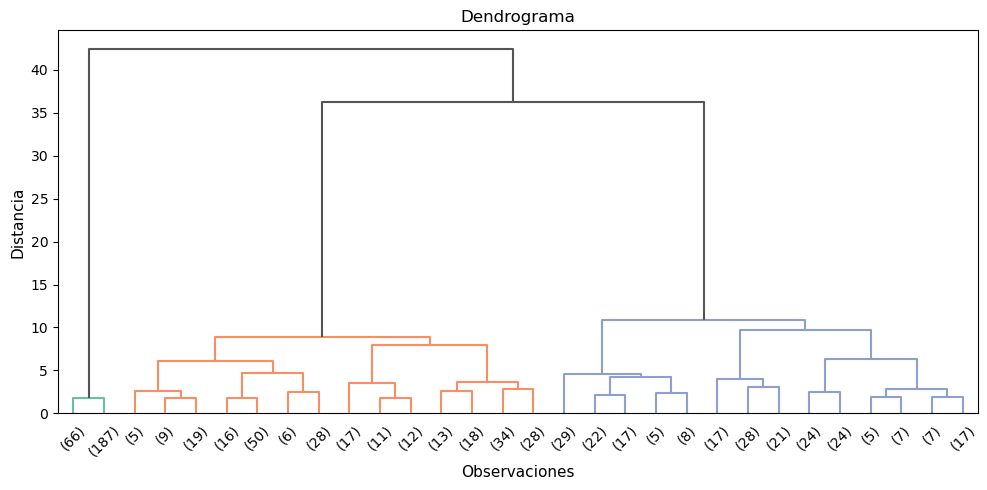

In [13]:
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage, set_link_color_palette
from matplotlib.colors import to_hex

# Calculamos el linkage
Z = linkage(X, method='ward')

# Dibujamos el dendrograma
colors = [to_hex(c) for c in plt.cm.Set2.colors]
set_link_color_palette(colors)

fig, ax = plt.subplots(figsize=(10, 5))
dendrogram(Z, ax=ax, truncate_mode="lastp", above_threshold_color="#555555")
set_link_color_palette(None)
ax.set_title("Dendrograma", fontsize=12)
ax.set_xlabel("Observaciones", fontsize=11)
ax.set_ylabel("Distancia", fontsize=11)
plt.tight_layout()
plt.show()

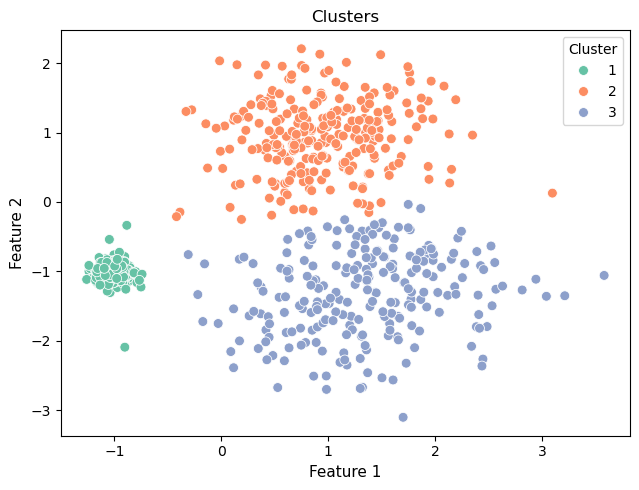

In [14]:
# Cortamos el dendrograma en el nivel deseado para formar clusters
clusters_scipy = fcluster(Z, t=3, criterion='maxclust')

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=clusters_scipy, palette=colors[:3], ax=ax, s=50)
ax.set_title("Clusters", fontsize=12)
ax.set_xlabel("Feature 1", fontsize=11)
ax.set_ylabel("Feature 2", fontsize=11)
ax.legend(title="Cluster", fontsize=10)
plt.tight_layout()
plt.show()